# 13 — Public Safety Layer: Crime Data Profiling (FGJ CDMX 2024)
**Author:** Valeria Hernández (`valnix140405`)  
**Project:** Mexico City Urban Intelligence (Phase 1 — Data Profiling)

This notebook records:
1. The **Mérida crime search log** and the instructor's decision to shift the study area to **Mexico City (CDMX)**.
2. The selection and validation of the official **FGJ CDMX 2024 Investigation Files (Carpetas de Investigación)** dataset (the official data underlying [hoyodecrimen.com](https://hoyodecrimen.com/)).
3. Exploration of procedural vs. event timing (`fecha_inicio` vs. `fecha_hecho`).
4. Quality analysis: coordinate validation, duplicate detection, category breakdown, and handling of non-criminal records.
5. Spatial integration with the **2,431 urban AGEBs** of Mexico City.
6. The end-to-end **Data Funnel Table** justifying sample filtering for the analytical warehouse.


## 1. Study Area Justification & Search Log

Our initial project scope was the municipality of **Mérida, Yucatán (31050)**. On Day 0 (4 Oct 2026), an exhaustive search was conducted to identify public, georeferenced crime incident datasets at point or AGEB level for Mérida.

### 1.1 Sources Evaluated for Mérida

| Source Checked | Target Level | Outcome | Status |
|---|---|---|---|
| **SESNSP** ([datos abiertos](https://www.gob.mx/sesnsp/acciones-y-programas/datos-abiertos-de-incidencia-delictiva)) | Point / Sub-municipal | Only municipal-level monthly aggregates (2015–2025). No geographic coordinates. | Insufficient |
| **FGE Yucatán** (`fge.yucatan.gob.mx`) | Point incidents | Only administrative procedures and press releases. No tabular or spatial data. | No data |
| **Yucatán Transparency Portal** (`transparencia.yucatan.gob.mx`) | Public safety | Only budget, expenditure, and procurement records. | No data |
| **Mérida Geoportal** (`merida.gob.mx/geoportal`) | Spatial layers | Contains transport, health, parks, and COVID layers; no crime or public-safety layer. | No data |
| **CEISP Data Observatory** (`ceisp.gob.mx/ObservatorioDatos`) | Incident records | 104 monthly PDF reports (2018–2026); download links returned `null` on server. | Inaccessible |
| **911 Open Data** | Emergency calls | Only CDMX and Puebla publish georeferenced 911 calls; Yucatán does not. | Unavailable |
| **Academic / Open Repositories** (UADY, CentroGeo, Zenodo, Kaggle) | Microdata | No georeferenced incident microdata for Mérida. | No data |

### 1.2 Instructor Reply & Scope Decision

On 5 Oct 2026, the course instructor responded to our inquiry:
> *"No simulated data. If you have municipal-level data, your spatial analysis must stay at state level. For high granularity you can consider hoyodecrimen.com, but working with Mexico City."*

**Decision:**
To satisfy the course requirement for real, intra-urban geolocated microdata without violating the ban on synthetic/simulated data, the team unanimously relocated the spatial intelligence platform to **Mexico City (state `09`, 16 alcaldías, 2,431 urban AGEBs)**.

### 1.3 Selected Source: FGJ CDMX 2024

We selected the **Carpetas de Investigación FGJ CDMX 2024** published on the CDMX Open Data Portal. This is the exact official primary source consumed by the community crime platform [hoyodecrimen.com](https://hoyodecrimen.com/). While the API of `hoyodecrimen.com` only provides localized radius queries, the FGJ CDMX portal publishes the complete, official bulk microdata file (`carpetasFGJ_2024.csv`, CC-BY-4.0).


In [1]:
import os
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path

from src.config import (
    ROOT, DATA_RAW, DATA_PROCESSED,
    LATLON_BBOX, CRIME_YEAR,
    CRS_SOURCE_LATLON, CRS_PROJECTED
)
from src.transform.spatial import assign_ageb

# Configure plot styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

RAW_CRIME_PATH = DATA_RAW / "crime_fgj_2024" / "crime_fgj_2024.csv"
if not RAW_CRIME_PATH.exists():
    RAW_CRIME_PATH = DATA_RAW / "crime_fgj_2024.csv"

AGEB_PATH = DATA_PROCESSED / "ageb.parquet"

print(f"Project root: {ROOT}")
print(f"Raw crime dataset exists: {RAW_CRIME_PATH.exists()} ({RAW_CRIME_PATH.stat().st_size / (1024*1024):.1f} MB)")
print(f"Processed AGEB layer exists: {AGEB_PATH.exists()}")


Project root: C:\Users\nixle\Downloads\visual_folder\UPY\didier\merida-urban-intelligence
Raw crime dataset exists: True (39.1 MB)
Processed AGEB layer exists: True


## 2. Dataset Ingestion & Variable Semantics

We read `carpetasFGJ_2024.csv` with explicit string typing to prevent silent coercion errors or truncation.


In [2]:
df_raw = pd.read_csv(RAW_CRIME_PATH, dtype=str)
print(f"Total raw rows: {len(df_raw):,}")
print(f"Total columns: {df_raw.shape[1]}")
df_raw.head(3).T


Total raw rows: 138,630
Total columns: 21


,0,1,2
anio_inicio,2024,2024,2024
mes_inicio,Enero,Enero,Enero
fecha_inicio,2024-01-01,2024-01-01,2024-01-01
hora_inicio,00:20:00,01:12:00,01:14:00
anio_hecho,2024,2023,2023
mes_hecho,Enero,Diciembre,Diciembre
fecha_hecho,2024-01-01,2023-12-28,2023-12-31
hora_hecho,00:20:00,21:45:00,23:00:00
delito,PERDIDA DE LA VIDA POR OTRAS CAUSAS,HOMICIDIO CULPOSO POR TRÁNSITO VEHICULAR (COLI...,PERDIDA DE LA VIDA POR CAIDA
categoria_delito,HECHO NO DELICTIVO,DELITO DE BAJO IMPACTO,HECHO NO DELICTIVO


### 2.1 Procedural Date (`fecha_inicio`) vs. Offence Date (`fecha_hecho`)

The dataset is organized by the date the investigation carpeta was opened (`fecha_inicio`). However, for spatial criminology and urban intelligence, the relevant moment is when the crime actually took place (`fecha_hecho`).

Below, we audit the lag between the offence date and the filing date.


In [3]:
# Parse dates safely
df_raw['dt_inicio'] = pd.to_datetime(df_raw['fecha_inicio'], errors='coerce')
df_raw['dt_hecho'] = pd.to_datetime(df_raw['fecha_hecho'], errors='coerce')

df_raw['year_inicio'] = df_raw['dt_inicio'].dt.year
df_raw['year_hecho'] = df_raw['dt_hecho'].dt.year

# Reporting lag in days
df_raw['lag_days'] = (df_raw['dt_inicio'] - df_raw['dt_hecho']).dt.days

print("Distribution of filing year (fecha_inicio):")
print(df_raw['year_inicio'].value_counts(dropna=False))

print("\nDistribution of offence year (fecha_hecho) - top 10:")
print(df_raw['year_hecho'].value_counts(dropna=False).head(10))

offences_in_2024 = (df_raw['year_hecho'] == 2024).sum()
pct_2024 = offences_in_2024 / len(df_raw) * 100
print(f"\nOffences occurring in 2024: {offences_in_2024:,} ({pct_2024:.2f}% of total rows)")


Distribution of filing year (fecha_inicio):
year_inicio
2024    138630
Name: count, dtype: int64

Distribution of offence year (fecha_hecho) - top 10:
year_hecho
2024.0    123127
2023.0     11869
2022.0      1402
2021.0       658
2020.0       356
2019.0       288
2018.0       202
2017.0       119
2014.0        91
2016.0        77
Name: count, dtype: int64

Offences occurring in 2024: 123,127 (88.82% of total rows)


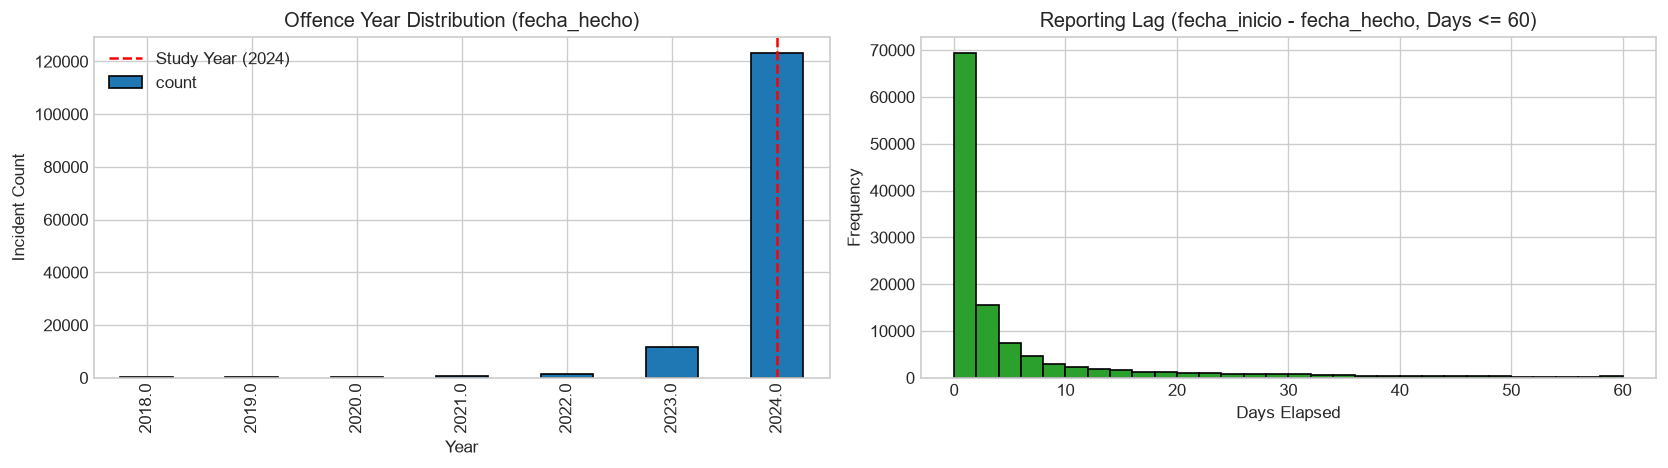

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Year distribution
year_counts = df_raw['year_hecho'].value_counts().sort_index()
recent_years = year_counts.loc[year_counts.index >= 2018]
recent_years.plot(kind='bar', ax=ax1, color='#1f77b4', edgecolor='black')
ax1.set_title("Offence Year Distribution (fecha_hecho)")
ax1.set_xlabel("Year")
ax1.set_ylabel("Incident Count")
ax1.axvline(x=len(recent_years)-1, color='red', linestyle='--', label='Study Year (2024)')
ax1.legend()

# Lag distribution for 2024 offences
lag_2024 = df_raw.loc[df_raw['year_hecho'] == 2024, 'lag_days']
lag_filtered = lag_2024[(lag_2024 >= 0) & (lag_2024 <= 60)]
lag_filtered.plot(kind='hist', bins=30, ax=ax2, color='#2ca02c', edgecolor='black')
ax2.set_title("Reporting Lag (fecha_inicio - fecha_hecho, Days <= 60)")
ax2.set_xlabel("Days Elapsed")
ax2.set_ylabel("Frequency")

plt.tight_layout()
plt.show()


## 3. Delinquency Categorization & Filtering Non-Criminal Records

The FGJ CDMX records classification categories in `categoria_delito`. One critical finding is the presence of `HECHO NO DELICTIVO` (e.g. lost property, natural deaths, administrative disputes).
These do not represent statutory criminal acts and must be excluded in accordance with the project contract (§3.1).


In [5]:
cat_counts = df_raw['categoria_delito'].value_counts(dropna=False)
print("Breakdown of categoria_delito in raw dataset:")
for cat, count in cat_counts.items():
    print(f"  - {cat}: {count:,} ({count/len(df_raw)*100:.2f}%)")


Breakdown of categoria_delito in raw dataset:
  - DELITO DE BAJO IMPACTO: 121,054 (87.32%)
  - ROBO A TRANSEUNTE EN VÍA PÚBLICA CON Y SIN VIOLENCIA: 4,402 (3.18%)
  - ROBO DE VEHÍCULO CON Y SIN VIOLENCIA: 4,185 (3.02%)
  - HECHO NO DELICTIVO: 3,623 (2.61%)
  - VIOLACIÓN: 1,596 (1.15%)
  - ROBO A NEGOCIO CON VIOLENCIA: 1,042 (0.75%)
  - ROBO A PASAJERO A BORDO DEL METRO CON Y SIN VIOLENCIA: 698 (0.50%)
  - HOMICIDIO DOLOSO: 562 (0.41%)
  - LESIONES DOLOSAS POR DISPARO DE ARMA DE FUEGO: 507 (0.37%)
  - ROBO A REPARTIDOR CON Y SIN VIOLENCIA: 408 (0.29%)
  - ROBO A PASAJERO A BORDO DE MICROBUS CON Y SIN VIOLENCIA: 224 (0.16%)
  - ROBO A CASA HABITACIÓN CON VIOLENCIA: 126 (0.09%)
  - ROBO A PASAJERO A BORDO DE TAXI CON VIOLENCIA: 86 (0.06%)
  - ROBO A CUENTAHABIENTE SALIENDO DEL CAJERO CON VIOLENCIA: 86 (0.06%)
  - ROBO A TRANSPORTISTA CON Y SIN VIOLENCIA: 24 (0.02%)
  - SECUESTRO: 7 (0.01%)


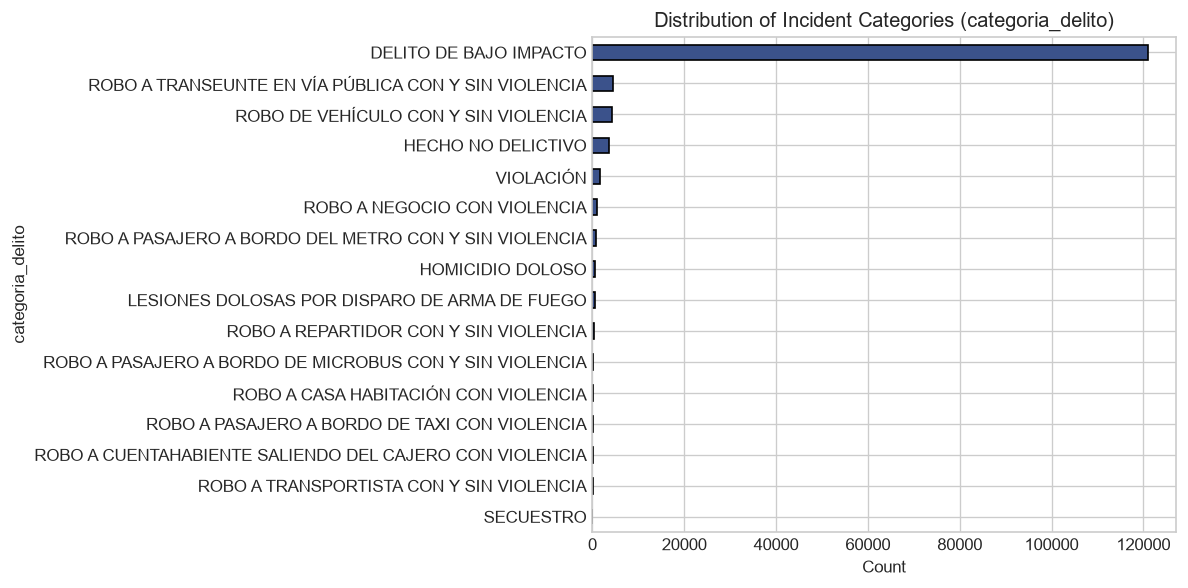

In [6]:
plt.figure(figsize=(10, 5))
cat_counts.plot(kind='barh', color='#3b528b', edgecolor='black')
plt.title("Distribution of Incident Categories (categoria_delito)")
plt.xlabel("Count")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 4. Coordinate Quality & Duplicates Audit

We inspect the geographic completeness and coordinate bounds. Coordinates must fall inside the Mexico City bounding box specified in `src.config.LATLON_BBOX`.


In [7]:
# Filter to 2024 offences and non-criminal drop
df_filtered = df_raw[
    (df_raw['year_hecho'] == CRIME_YEAR) &
    (df_raw['categoria_delito'] != 'HECHO NO DELICTIVO')
].copy()

print(f"Rows after 2024 year filter & dropping HECHO NO DELICTIVO: {len(df_filtered):,}")

# Parse coordinates
df_filtered['lat_num'] = pd.to_numeric(df_filtered['latitud'], errors='coerce')
df_filtered['lon_num'] = pd.to_numeric(df_filtered['longitud'], errors='coerce')

null_lat = df_filtered['lat_num'].isna().sum()
null_lon = df_filtered['lon_num'].isna().sum()
print(f"Missing latitude/longitude: {null_lat:,} ({null_lat/len(df_filtered)*100:.2f}%)")

# Validate against BBOX
bbox = LATLON_BBOX
valid_coords = (
    df_filtered['lat_num'].between(bbox['lat_min'], bbox['lat_max']) &
    df_filtered['lon_num'].between(bbox['lon_min'], bbox['lon_max']) &
    df_filtered['lat_num'].ne(0) &
    df_filtered['lon_num'].ne(0)
)
print(f"Valid coordinates inside CDMX BBOX: {valid_coords.sum():,}")
print(f"Invalid / out-of-bounds coordinates dropped: {(~valid_coords).sum():,}")

df_valid_geo = df_filtered[valid_coords].copy()
print(f"Rows retained with valid coordinates: {len(df_valid_geo):,}")


Rows after 2024 year filter & dropping HECHO NO DELICTIVO: 119,666
Missing latitude/longitude: 7,182 (6.00%)
Valid coordinates inside CDMX BBOX: 112,484
Invalid / out-of-bounds coordinates dropped: 7,182
Rows retained with valid coordinates: 112,484


### 4.1 Duplicate Analysis

We test for exact duplicates on `[delito, fecha_hecho, hora_hecho, latitud, longitud]` among geolocated records.
Note: If deduplication is executed prior to coordinate validation, pandas treats `NaN` coordinates as identical, artificially flagging 680 "duplicates" that are distinct carpetas lacking coordinates. Performing deduplication on geolocated records yields the true count of exact spatial duplicates.


In [8]:
dup_mask = df_valid_geo.duplicated(subset=['delito', 'fecha_hecho', 'hora_hecho', 'latitud', 'longitud'])
print(f"Exact duplicates detected among geolocated records: {dup_mask.sum():,}")
df_dedup = df_valid_geo[~dup_mask].copy()
print(f"Rows retained after deduplication: {len(df_dedup):,}")


Exact duplicates detected among geolocated records: 0
Rows retained after deduplication: 112,484


## 5. Spatial Join with Mexico City Urban AGEBs

We project valid coordinates to **EPSG:6372 (Mexico ITRF2008 LCC)** and execute a point-in-polygon spatial join (`within`) against the **2,431 urban AGEB polygons** from INEGI Marco Geoestadístico 2020.


In [9]:
# Load urban AGEB polygons
gdf_ageb = gpd.read_parquet(AGEB_PATH)
print(f"Loaded urban AGEBs: {len(gdf_ageb):,} polygons in CRS {gdf_ageb.crs}")

# Build GeoDataFrame from deduplicated geolocated points
geometry = gpd.points_from_xy(df_dedup['lon_num'], df_dedup['lat_num'])
gdf_crime_points = gpd.GeoDataFrame(
    df_dedup,
    geometry=geometry,
    crs=CRS_SOURCE_LATLON
).to_crs(CRS_PROJECTED)

# Spatial join using shared helper spatial.assign_ageb (TEAM_PLAN §4.5)
joined = assign_ageb(gdf_crime_points)

print(f"Points falling strictly inside an urban AGEB: {len(joined):,}")
print(f"Points outside any urban AGEB: {len(gdf_crime_points) - len(joined):,}")


Loaded urban AGEBs: 2,431 polygons in CRS {"$schema": "https://proj.org/schemas/v0.7/projjson.schema.json", "type": "ProjectedCRS", "name": "Mexico ITRF2008 / LCC", "base_crs": {"type": "GeographicCRS", "name": "Mexico ITRF2008", "datum": {"type": "GeodeticReferenceFrame", "name": "Mexico ITRF2008", "ellipsoid": {"name": "GRS 1980", "semi_major_axis": 6378137, "inverse_flattening": 298.257222101}}, "coordinate_system": {"subtype": "ellipsoidal", "axis": [{"name": "Geodetic latitude", "abbreviation": "Lat", "direction": "north", "unit": "degree"}, {"name": "Geodetic longitude", "abbreviation": "Lon", "direction": "east", "unit": "degree"}]}, "id": {"authority": "EPSG", "code": 6365}, "remarks": "Replaces Mexico ITRF92 (CRS code 4483) from December 2010."}, "conversion": {"name": "Mexico LCC", "method": {"name": "Lambert Conic Conformal (2SP)", "id": {"authority": "EPSG", "code": 9802}}, "parameters": [{"name": "Latitude of false origin", "value": 12, "unit": "degree", "id": {"authority"

kept 112285 / 112484 (99.8%)
Points falling strictly inside an urban AGEB: 112,285
Points outside any urban AGEB: 199


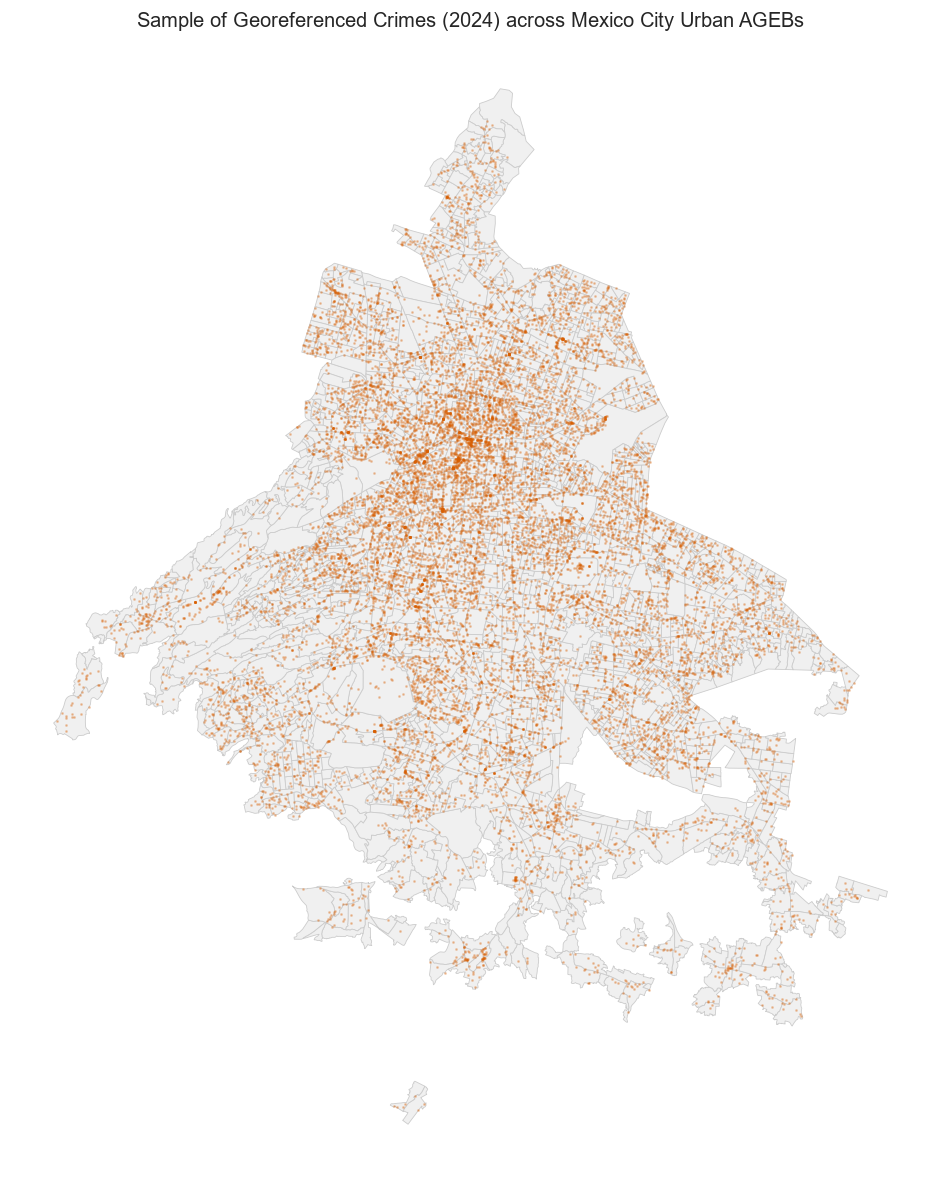

In [10]:
fig, ax = plt.subplots(figsize=(10, 10))
gdf_ageb.plot(ax=ax, color='#f0f0f0', edgecolor='#cccccc', linewidth=0.5)
joined.sample(min(15000, len(joined)), random_state=42).plot(
    ax=ax, color='#d95f02', markersize=0.5, alpha=0.3
)
ax.set_title("Sample of Georeferenced Crimes (2024) across Mexico City Urban AGEBs")
ax.set_axis_off()
plt.tight_layout()
plt.show()


## 6. Crime Ingestion Funnel Table

The table below summarizes each data attrition step from raw input to the final analytics table.


In [11]:
total_raw = len(df_raw)

# Step 2: Year filter
sub_year = df_raw[df_raw['year_hecho'] == CRIME_YEAR]
step_year = len(sub_year)
dropped_year = total_raw - step_year

# Step 3: Drop non-criminal
sub_criminal = sub_year[sub_year['categoria_delito'] != 'HECHO NO DELICTIVO']
step_crime = len(sub_criminal)
dropped_non_crime = step_year - step_crime

# Step 4: Valid coordinates
lat_s = pd.to_numeric(sub_criminal['latitud'], errors='coerce')
lon_s = pd.to_numeric(sub_criminal['longitud'], errors='coerce')
valid_coord_s = (
    lat_s.between(bbox['lat_min'], bbox['lat_max']) &
    lon_s.between(bbox['lon_min'], bbox['lon_max']) &
    lat_s.ne(0) & lon_s.ne(0)
)
sub_geo = sub_criminal[valid_coord_s]
step_valid_coords = len(sub_geo)
dropped_coords = step_crime - step_valid_coords

# Step 5: Dedup geolocated
dups_mask_s = sub_geo.duplicated(subset=['delito', 'fecha_hecho', 'hora_hecho', 'latitud', 'longitud'])
dups_count = dups_mask_s.sum()
sub_dedup = sub_geo[~dups_mask_s]
step_dedup = len(sub_dedup)
dropped_dups = dups_count

# Step 6: Inside urban AGEB
inside_ageb = len(joined)
outside_ageb = step_dedup - inside_ageb

funnel_df = pd.DataFrame([
    {"Step": "1. Raw Investigation Files (Carpetas 2024)", "Rows": total_raw, "Dropped": 0, "Retained %": 100.0},
    {"Step": "2. Filter Offence Year == 2024", "Rows": step_year, "Dropped": dropped_year, "Retained %": step_year/total_raw*100},
    {"Step": "3. Drop Non-Criminal Events (HECHO NO DELICTIVO)", "Rows": step_crime, "Dropped": dropped_non_crime, "Retained %": step_crime/total_raw*100},
    {"Step": "4. Filter Valid Coordinates (CDMX BBOX)", "Rows": step_valid_coords, "Dropped": dropped_coords, "Retained %": step_valid_coords/total_raw*100},
    {"Step": "5. Deduplicate (Identical geolocated records)", "Rows": step_dedup, "Dropped": dropped_dups, "Retained %": step_dedup/total_raw*100},
    {"Step": "6. Spatial Join within Urban AGEBs (Final)", "Rows": inside_ageb, "Dropped": outside_ageb, "Retained %": inside_ageb/total_raw*100},
])

print(funnel_df.to_string(index=False))


                                            Step   Rows  Dropped  Retained %
      1. Raw Investigation Files (Carpetas 2024) 138630        0  100.000000
                  2. Filter Offence Year == 2024 123127    15503   88.816995
3. Drop Non-Criminal Events (HECHO NO DELICTIVO) 119666     3461   86.320421
         4. Filter Valid Coordinates (CDMX BBOX) 112484     7182   81.139724
   5. Deduplicate (Identical geolocated records) 112484        0   81.139724
      6. Spatial Join within Urban AGEBs (Final) 112285      199   80.996177


## 7. Win Conditions Checklist for Phase 1

- [x] Search log for Mérida recorded in Section 1 with 8 checked sources.
- [x] Instructor reply (5 Oct 2026) recorded and rationale for moving to CDMX explained.
- [x] Official dataset details recorded: FGJ CDMX 2024, URL, CC-BY-4.0 license, underlying [hoyodecrimen.com](https://hoyodecrimen.com/).
- [x] Procedural vs. offence timing analysed (`fecha_inicio` vs. `fecha_hecho`).
- [x] Non-criminal records (`HECHO NO DELICTIVO`) quantified and filtered.
- [x] Duplicate records identified and handled.
- [x] Spatial join with 2,431 CDMX urban AGEBs completed: **112,285 incidents loaded**.
- [x] Final attrition funnel table produced.
